In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import sparrow as sp
import spatialdata as sd
from napari_spatialdata import Interactive

import matplotlib.pyplot as plt
# need to install spatialdata plot for this, pip install git+https://github.com/scverse/spatialdata-plot.git@main
import spatialdata_plot
import spatialdata_io
from sparrow.io._visium_hd import visium_hd


the value of the environment variable BASIC_DCT_BACKEND is not in ["JAX","SCIPY"]
2024-11-21 11:11:48,206 - sparrow.image.pixel_clustering._clustering - WARNING - 'flowsom' not installed, 'sp.im.flowsom' will not be available.
2024-11-21 11:11:48,239 - sparrow.table.cell_clustering._clustering - WARNING - 'flowsom' not installed, 'sp.tb.flowsom' will not be available.
2024-11-21 11:11:48,258 - sparrow.plot - WARNING - 'joypy' not installed, 'sp.pl.ridgeplot_channel' and 'sp.pl.ridgeplot_channel_sample' will not be available.
2024-11-21 11:11:48,258 - sparrow.plot - WARNING - 'textalloc' not installed, 'sp.pl.group_snr_ratio' and 'sp.pl.snr_ratio' will not be available.


In [10]:

# sdata=sp.datasets.visium_hd_example( bin_size=[2,8,16], output = "/home/chananchidas/visium-hd/data/sdata_vis.zarr" )
# you should now be able to view expression levels in napari spatialdata, i.e.:

#sdata = visium_hd('/home/chananchidas/visium-hd/data/Visium_HD_MouseBrain/')

sdata = spatialdata_io.visium_hd('/home/chananchidas/visium-hd/data/Visium_HD_MouseBrain/',
                                    fullres_image_file="microscope_image/Visium_HD_Mouse_Brain_tissue_image.tif",
                                    annotate_table_by_labels=True)

# sdata = sd.read_zarr("/home/chananchidas/visium-hd/data/sdata_vis.zarr")
# Interactive(sdata=sdata )

/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


For even faster viewing, create an image layer of the expression levels with below code.

In [4]:
import dask.array as da
import numpy as np
from spatialdata import SpatialData
from spatialdata._types import ArrayLike
from spatialdata.models import Image2DModel
from spatialdata.transformations import get_transformation
from spatialdata_io._constants._constants import VisiumHDKeys
from xarray import DataArray

from sparrow.utils._keys import _REGION_KEY,_INSTANCE_KEY


# inspired by https://github.com/scverse/spatialdata/blob/b9eb240aacd0f68133c95b68ba27529e060ca0b6/src/spatialdata/_core/operations/rasterize_bins.py#L28
def _rasterize_bins( sdata: SpatialData, table_layer: str, obs_column: str | list[str] | None,
                    labels_layer: str)->DataArray:

    obs_column = [ obs_column ] if isinstance(obs_column, str ) else obs_column

    table = sdata[ table_layer ]

    row_key=VisiumHDKeys.ARRAY_ROW
    col_key=VisiumHDKeys.ARRAY_COL

    min_row, min_col = table.obs[row_key].min(), table.obs[col_key].min()
    n_rows, n_cols = table.obs[row_key].max() - min_row + 1, table.obs[col_key].max() - min_col + 1
    y = (table.obs[row_key] - min_row).values
    x = (table.obs[col_key] - min_col).values


    #labels_layer=table.obs[ _REGION_KEY ].cat.categories[0]

    if obs_column is None:

        dtype = table.X.dtype

        keys = table.var_names

        shape = (n_rows, n_cols)

        def channel_rasterization(block_id: tuple[int, int, int] | None) -> ArrayLike:

            image: ArrayLike = np.zeros((1, *shape), dtype=dtype)

            if block_id is None:
                return image

            col = table.X[:, block_id[0]]
            bins_indices, data = col.indices, col.data
            image[0, y[bins_indices], x[bins_indices]] = data

            return image

        image = da.map_blocks(
            channel_rasterization,
            chunks=((1,) * len(keys), *shape),
            dtype=np.uint32,
        )

    else:
        keys = obs_column
        image = np.zeros((len(obs_column), n_rows, n_cols))
        image[:, y, x] = table.obs[obs_column].values.T

    element=Image2DModel.parse( data = image, dims = ("c", "y", "x" ), transformations=get_transformation( sdata.labels[ labels_layer  ], get_all=True ), c_coords = keys )

    return element

Since sdata is a csr format (compressed sparse row), we should convert it to csc (compressed sparse column) for better efficiency, as we will mostly be querying based on the columns (=genes).

In [7]:
for tables_layer in [*sdata.tables]:
    adata = sdata[tables_layer]
    adata.var_names_make_unique()
    adata.X = adata.X.tocsc()

    del sdata[tables_layer]

    sdata[tables_layer] = adata

In [36]:
element=_rasterize_bins( sdata, table_layer="square_002um", obs_column=None,labels_layer="Visium_HD_Mouse_Brain_square_002um_labels")

# do not compute this element 'image_layer'!, it should stay lazy
sdata[ "image_layer" ] =element

In [ ]:
Interactive(sdata=sdata)

2024-11-20 16:07:58.225 | INFO     | napari_spatialdata._view:_on_layer_update:355 - Updating layer.
2024-11-20 16:07:58.239 | INFO     | napari_spatialdata._view:_on_layer_update:355 - Updating layer.
2024-11-20 16:08:12.733 | INFO     | napari_spatialdata._view:_on_layer_update:355 - Updating layer.
2024-11-20 16:08:12.774 | INFO     | napari_spatialdata._view:_on_layer_update:355 - Updating layer.
2024-11-20 16:08:12.834 | INFO     | napari_spatialdata._view:_on_layer_update:355 - Updating layer.
2024-11-20 16:08:14.415 | INFO     | napari_spatialdata._view:_on_layer_update:355 - Updating layer.
2024-11-20 16:08:14.457 | INFO     | napari_spatialdata._view:_on_layer_update:355 - Updating layer.


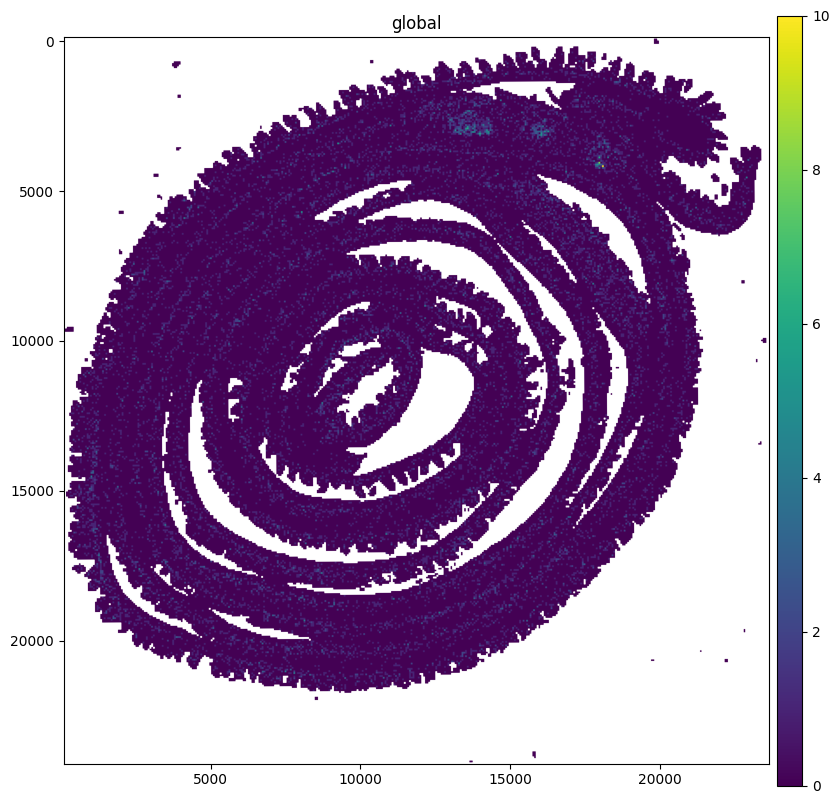

In [4]:
plt.figure(figsize=(10, 10))
ax = plt.gca()

labels_layer = "Visium_HD_Mouse_Small_Intestine_square_016um_labels"

gene_name =  "Tcea1"
sdata.pl.render_labels(labels_layer, color=gene_name, method="datashader", fill_alpha=1.0).pl.show(
    coordinate_systems="global", ax=ax
)

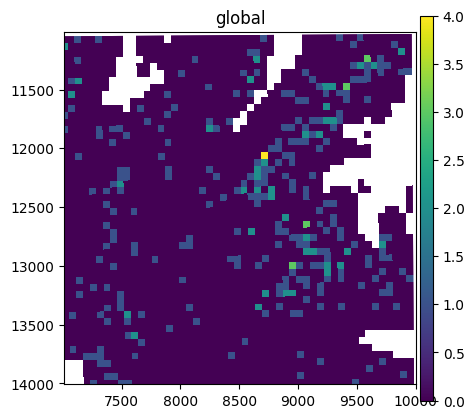

In [5]:
sdata_small = sdata.query.bounding_box(
    min_coordinate=[7000, 11000], max_coordinate=[10000, 14000], axes=("x", "y"), target_coordinate_system="global"
)

plt.figure(figsize=(5, 5))
ax = plt.gca()

labels_layer = "Visium_HD_Mouse_Small_Intestine_square_016um_labels"

gene_name =  "Tcea1"
sdata_small.pl.render_labels(labels_layer, color=gene_name, method="datashader", fill_alpha=1.0).pl.show(
    coordinate_systems="global", ax=ax
)

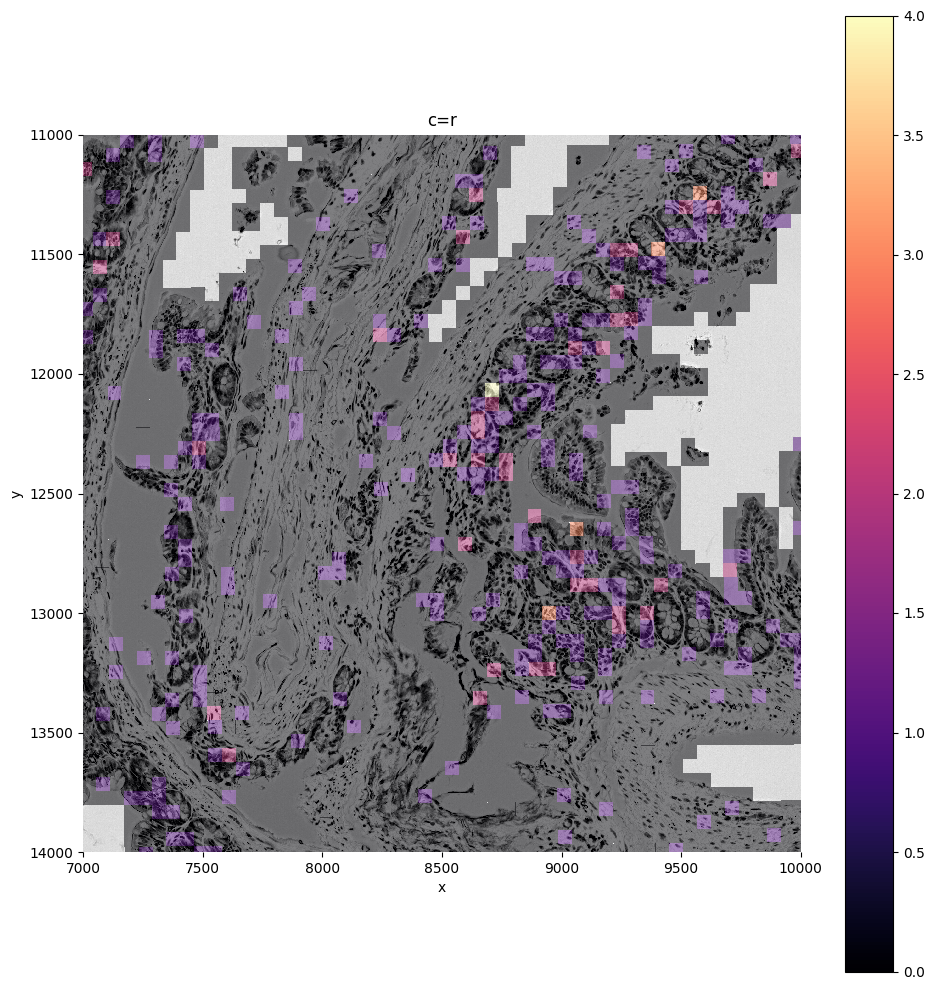

In [6]:
# or using plot_shapes from sparrow.
sp.pl.plot_shapes( sdata,
                  shapes_layer= "Visium_HD_Mouse_Small_Intestine_square_016um",
                  img_layer="Visium_HD_Mouse_Small_Intestine_full_image",
                  crd =[7000,10000,11000, 14000],
                  channel="r",
                  figsize=(10,10),
                  linewidth=0,
                  column= "Tcea1",
                  table_layer="square_016um",
                    )